. The Core Concept: Semantic Segmentation

Normally, an image classification model (like ResNet or VGG) looks at a picture of a cat and simply outputs the label "Cat."Semantic segmentation is much more granular. Instead of one label for the whole image, the model needs to output a label for every single pixel. For the Oxford-IIIT Pet dataset, every pixel in a $256 \times 256$ image must be classified into one of three categories:

Class 0: Background

Class 1: The Pet (the main body)

Class¨2: The Edge (the boundary/outline where the pet meets the background)

The Surgery: Classification models typically end in "Linear" (Dense) layers that crush the spatial dimensions into a single 1D array of probabilities. We need to "chop off" this head and replace it with a Segmentation Head. This usually involves adding Convolutional and Upsampling layers (like Transposed Convolutions) to scale the feature map back up to the original $256 \times 256$ resolution.

Freezing Layers: As the prompt hints, we shouldn't immediately train all the weights. We will likely start by "freezing" the pretrained backbone so its weights can't change, and only train our newly added segmentation head. Later, we can "unfreeze" the whole network and gently fine-tune it with a very small learning rate.

Validation & Early Stopping: We need to split our dataset into a Training Set and a Validation Set. We will monitor the model's performance on the Validation Set at the end of every epoch. If the validation performance stops improving (or gets worse, indicating overfitting), we trigger Early Stopping and halt training.

Evaluation: mIoU (Intersection over Union)

The competition evaluates us using mean Intersection over Union (mIoU).Think of it as a Venn diagram. For each of the three classes, the IoU formula looks like this:$$IoU = \frac{\text{Area of Overlap (Intersection)}}{\text{Area of Union}}$$

Intersection: The pixels where our model correctly guessed the class.

Union: All the pixels that were either predicted as that class OR are actually that class in the ground truth.An IoU of $1.0$ is a perfect match. The code provided computes this for all three classes separately and then averages them together to get the final score.

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Define the transformations
# We convert images to PyTorch Tensors and resize both images and masks to 256x256.
# Note: Masks use 'Nearest' interpolation so we don't accidentally create floating-point class labels.
transforms = v2.Compose([
    v2.Resize((256, 256), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) # Converts image to float [0.0, 1.0]
])

target_transforms = v2.Compose([
    v2.Resize((256, 256), interpolation=v2.InterpolationMode.NEAREST),
    v2.ToImage(),
    v2.ToDtype(torch.long, scale=False) # Masks remain as integers
])

# 2. Create a Custom Dataset Wrapper to fix the mask values
class PetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, transforms, target_transforms):
        # Download and load the base dataset
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )
        self.transforms = transforms
        self.target_transforms = target_transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        # Apply transforms to resize and convert to tensors
        image = self.transforms(image)
        mask = self.target_transforms(mask)

        # Squeeze the mask to remove the channel dimension (1, 256, 256) -> (256, 256)
        mask = mask.squeeze(0)

        # Remap mask values from [1, 2, 3] to [1, 0, 2] so Background is 0
        # Original: 1 (Pet), 2 (Background), 3 (Edge)
        new_mask = torch.zeros_like(mask)
        new_mask[mask == 1] = 1 # Pet stays 1
        new_mask[mask == 2] = 0 # Background becomes 0
        new_mask[mask == 3] = 2 # Edge becomes 2

        return image, new_mask



In [4]:
# 3. Download and initialize the datasets
print("Downloading and preparing datasets...")
train_dataset = PetSegmentationDataset(root='./data', split='trainval', transforms=transforms, target_transforms=target_transforms)
test_dataset = PetSegmentationDataset(root='./data', split='test', transforms=transforms, target_transforms=target_transforms)



100%|██████████| 792M/792M [01:06<00:00, 11.9MB/s] 


Extracting data\oxford-iiit-pet\images.tar.gz to data\oxford-iiit-pet


100%|██████████| 19.2M/19.2M [00:02<00:00, 6.87MB/s]


Extracting data\oxford-iiit-pet\annotations.tar.gz to data\oxford-iiit-pet


In [5]:
# 4. Create the DataLoaders
# Batch size of 16 is a safe starting point for most GPUs
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

Training images: 3680
Testing images: 3669


C:\Users\pkank\AppData\Local\Temp\ipykernel_32908\3174410438.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', 3)


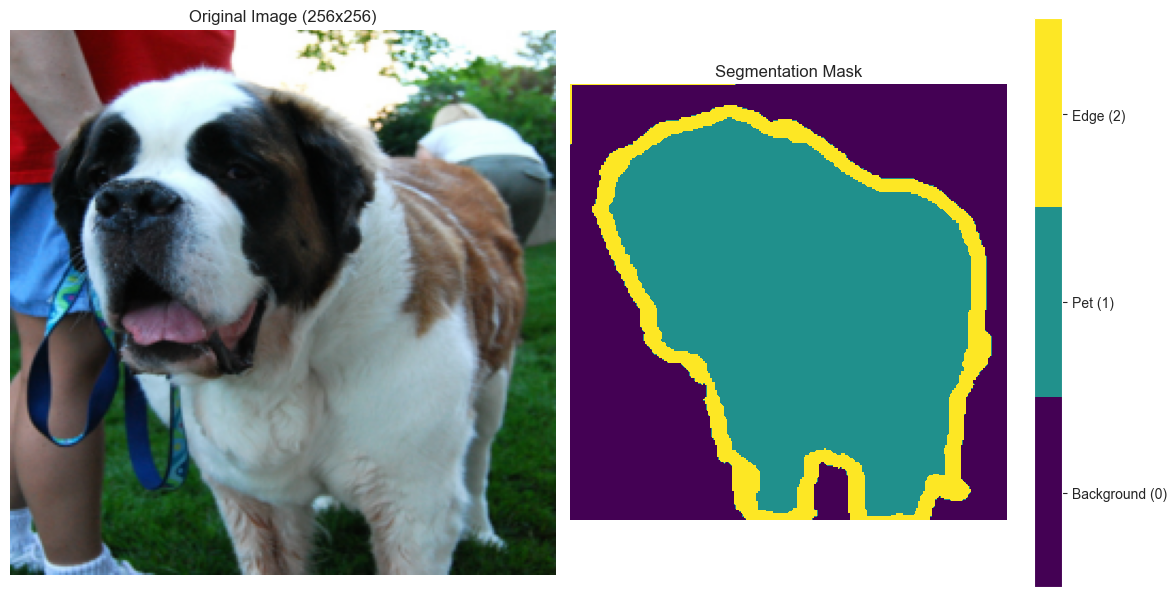

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Unique values in the mask: [0, 1, 2]


In [10]:
import matplotlib.pyplot as plt
import torch

# 1. Grab one batch of data from the training loader
images, masks = next(iter(train_loader))

# 2. Extract the first image and mask from the batch
img = images[4]
mask = masks[4]

# 3. Prepare the image for Matplotlib
# PyTorch image tensors are (Channels, Height, Width)
# Matplotlib expects (Height, Width, Channels), so we permute the dimensions.
img_np = img.permute(1, 2, 0).numpy()

# The mask is already (Height, Width), so we just convert to numpy
mask_np = mask.numpy()

# 4. Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the original image
axs[0].imshow(img_np)
axs[0].set_title("Original Image (256x256)")
axs[0].axis('off')

# Plot the segmentation mask
# We use vmin=0 and vmax=2 to ensure the colors consistently map to our 3 classes
# We also pick a specific colormap ('viridis') and force it to have exactly 3 colors
cmap = plt.cm.get_cmap('viridis', 3)
cax = axs[1].imshow(mask_np, cmap=cmap, vmin=0, vmax=2)
axs[1].set_title("Segmentation Mask")
axs[1].axis('off')

# Add a colorbar to act as a legend for our classes
cbar = fig.colorbar(cax, ax=axs[1], ticks=[0.33, 1.0, 1.66])
cbar.ax.set_yticklabels(['Background (0)', 'Pet (1)', 'Edge (2)'])

plt.tight_layout()
plt.show()

# 5. Print a sanity check to the console
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Unique values in the mask: {torch.unique(mask).tolist()}")

In [11]:
import torchvision.models.segmentation as segmentation
import torch.nn as nn

# 1. Load the Pretrained Model
# We use 'DEFAULT' to get the best available pretrained weights (trained on COCO dataset)
print("Downloading pretrained FCN-ResNet50...")
model = segmentation.fcn_resnet50(weights=segmentation.FCN_ResNet50_Weights.DEFAULT)

# 2. Freeze the Backbone (The "Hint" from your assignment)
# The backbone is the ResNet50 part that extracts features (edges, textures, shapes).
# We freeze it by telling PyTorch NOT to calculate gradients for these parameters.
for param in model.backbone.parameters():
    param.requires_grad = False
print("Backbone frozen.")

# 3. Modify the Classifier Head (The Surgery)
# The FCN model has a 'classifier' module. Let's look at the very last layer of it.
# Originally, it's a Convolutional layer outputting 21 classes.
original_final_layer = model.classifier[4]
print(f"\nOriginal final layer: {original_final_layer}")

# We extract the number of input channels feeding into that final layer (it's 512 for this model)
in_channels = original_final_layer.in_channels

# We create a brand new Convolutional layer that takes 512 channels in, but outputs 3!
# A 1x1 kernel is used just to change the depth/channels without changing the height/width.
model.classifier[4] = nn.Conv2d(in_channels, out_channels=3, kernel_size=(1, 1), stride=(1, 1))

print(f"New final layer: {model.classifier[4]}\n")

# Let's do a quick test pass with a dummy image to see the dictionary output!
# We create a fake image of zeros matching our batch shape: (1 image, 3 colors, 256 height, 256 width)
dummy_image = torch.zeros((1, 3, 256, 256))

# Put the model in evaluation mode for the test
model.eval()
output = model(dummy_image)

print("Model output type:", type(output))
print("Keys in the output dictionary:", output.keys())
print("Shape of the 'out' tensor:", output['out'].shape)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to C:\Users\pkank/.cache\torch\hub\checkpoints\fcn_resnet50_coco-1167a1af.pth
100%|██████████| 135M/135M [00:01<00:00, 89.5MB/s] 


Backbone frozen.

Original final layer: Conv2d(512, 21, kernel_size=(1, 1), stride=(1, 1))
New final layer: Conv2d(512, 3, kernel_size=(1, 1), stride=(1, 1))

Model output type: <class 'collections.OrderedDict'>
Keys in the output dictionary: odict_keys(['out', 'aux'])
Shape of the 'out' tensor: torch.Size([1, 3, 256, 256])


Original final layer: ... 21 ...: This confirms the model was originally built to predict 21 different things (the standard for the dataset it was originally trained on).

New final layer: ... 3 ...: This confirms our surgery worked! It is now wired to output exactly 3 things (Background, Pet, Edge).

Shape of the 'out' tensor: torch.Size([1, 3, 256, 256]): This is the golden ticket. 1 image, 3 classes, 256 height, 256 width. It is mathematically perfectly matched to the masks we prepared in Step 1.

feet, there are 512 numbers stacked on top of each other. These are the 512 "features" the network found for that specific pixel location (e.g., "furriness," "brown color," "sharp contrast," etc.).Here is what the $1 \times 1$ convolution does to that stack:It assigns a weight (a multiplier) to every single one of those 512 numbers.It multiplies the 512 feature numbers by their 512 weights.It adds all those results together into one single number.

Right now, our final 1x1 Convolutional layer spits out 3 numbers for every single pixel.

In deep learning, these raw output numbers are called Logits. They are not percentages, and they are not class labels (0, 1, or 2). They are just raw, unbounded mathematical scores that can be positive, negative, or zero.

For a single pixel, the model's output might look like this:

Score for Background (Class 0): -2.4

Score for Pet (Class 1): 8.7

Score for Edge (Class 2): 1.1

In professional computer vision, people often combine them, doing something like: Total Loss = CrossEntropyLoss + DiceLoss to get the best of both worlds!

In [12]:
import torch.optim as optim

# 1. Setup the Device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Training on device: {device}")

# 2. Define the Loss Function
# PyTorch's CrossEntropyLoss is magical. It expects our raw outputs (Logits) to be shape [Batch, 3, 256, 256]
# and our actual masks to be shape [Batch, 256, 256] containing the integers 0, 1, or 2.
# It automatically handles the Softmax percentages behind the scenes!
criterion = nn.CrossEntropyLoss()

# 3. Define the Optimizer
# CRITICAL: We only want to train the "head" we just added.
# We filter out all the frozen backbone parameters so the optimizer only updates our new weights.
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=0.001)

# 4. The Training Loop (Running just 1 epoch to test)
num_epochs = 1

print("\nStarting Training...")
for epoch in range(num_epochs):
    model.train() # Tell the model it is in training mode (enables dropout, batchnorm updates, etc.)
    running_loss = 0.0

    # Loop through our batches of data
    for i, (images, masks) in enumerate(train_loader):
        # Move data to the same device as the model (GPU)
        images = images.to(device)
        masks = masks.to(device)

        # Step A: Clear old gradients from the last step
        optimizer.zero_grad()

        # Step B: Forward Pass (Have the model make a guess)
        outputs = model(images)['out']

        # Step C: Calculate the Loss (How bad was the guess?)
        loss = criterion(outputs, masks)

        # Step D: Backward Pass (Calculate how to fix the weights)
        loss.backward()

        # Step E: Optimizer Step (Actually update the weights)
        optimizer.step()

        running_loss += loss.item()

        # Print an update every 10 batches so we know it's working
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    # Print the average loss for the whole epoch
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Completed. Average Loss: {epoch_loss:.4f}")

Training on device: cpu

Starting Training...
Epoch [1/1], Batch [10/230], Loss: 0.3670
Epoch [1/1], Batch [20/230], Loss: 0.2818
Epoch [1/1], Batch [30/230], Loss: 0.2545
Epoch [1/1], Batch [40/230], Loss: 0.3625
Epoch [1/1], Batch [50/230], Loss: 0.2443
Epoch [1/1], Batch [60/230], Loss: 0.2545
Epoch [1/1], Batch [70/230], Loss: 0.2949
Epoch [1/1], Batch [80/230], Loss: 0.3506
Epoch [1/1], Batch [90/230], Loss: 0.2498
Epoch [1/1], Batch [100/230], Loss: 0.2827
Epoch [1/1], Batch [110/230], Loss: 0.2292
Epoch [1/1], Batch [120/230], Loss: 0.2528
Epoch [1/1], Batch [130/230], Loss: 0.2281
Epoch [1/1], Batch [140/230], Loss: 0.2537
Epoch [1/1], Batch [150/230], Loss: 0.2427
Epoch [1/1], Batch [160/230], Loss: 0.2465
Epoch [1/1], Batch [170/230], Loss: 0.2443
Epoch [1/1], Batch [180/230], Loss: 0.2221
Epoch [1/1], Batch [190/230], Loss: 0.2432
Epoch [1/1], Batch [200/230], Loss: 0.3404
Epoch [1/1], Batch [210/230], Loss: 0.2809
Epoch [1/1], Batch [220/230], Loss: 0.2778
Epoch [1/1], Batc

In [ ]:
#TODO: --add wandb statistics to better observe the results